# Study 15 — Can we find a genuine ability change when we do not know where it happened?

Study 13 asked whether observed results could distinguish a genuine ability change from ordinary random variation.

But it gave the analysis one major advantage:

> **We told it exactly where the change happened.**

Study 14 removed that advantage and searched across an entire career.

But there was deliberately **no genuine change to find**.

That produced a different problem:

> **If we search through enough ordinary random variation, some periods will look unusually strong even when ability never changed.**

We now combine those two problems.

In this study, the player's true frame-win probability will begin at **58%** and, at one point during the career, permanently increase to **64%**.

The change will be known to us when constructing the simulation.

It will **not** be revealed to the detector.

The detector will see only the sequence of wins and losses and must search through the career for evidence that the player's ability improved.

There will still be:

- only one permanent ability change;
- independent frames;
- one fixed 250-frame window;
- no momentum;
- no opponent effects;
- no parameter uncertainty;
- no alternative window lengths;
- no formal change-point algorithm.

This creates a harder problem than either of the previous studies considered alone.

The career now contains both:

- a **real signal** caused by the genuine improvement;
- **random peaks** that may look like competing evidence of improvement.

The central question is:

> **If a genuine improvement happened somewhere in the career, can a search through noisy results correctly identify where it occurred?**

Study 13 asked:

> **Can we recognise a change when told where to look?**

Study 14 asked:

> **What happens when we search everywhere but nothing actually changed?**

Study 15 asks:

> **What happens when we must search everywhere and something really did change?**

The aim is not yet to build a sophisticated change-point detector.

It is to establish the basic identification problem:

> **Once the location of a genuine change is hidden, finding strong evidence is not enough — we must also ask whether the strongest-looking evidence actually points us to the real change.**

## Experimental design

We will keep the setup deliberately close to Studies 13 and 14.

Each simulated career will contain **5,000 frames**.

The player's true frame-win probability will be:

- **58% before the change**;
- **64% after the change**.

There will be one permanent change at a single point in the career.

We will know where that change occurred because we created the simulated data.

The detector will not.

It will receive only the sequence of frame results.

As in Study 14, we will examine the career using a fixed **250-frame rolling window**.

For every possible window, we will calculate the number of wins contained within those 250 frames.

We then need a deliberately simple way to search for the apparent improvement.

A natural first attempt is to ask:

> **Where does a 250-frame window show the strongest increase compared with the 250 frames immediately before it?**

For each possible location with enough history on both sides, we will therefore compare:

- the number of wins in the preceding 250 frames;
- the number of wins in the following 250 frames.

The search statistic will simply be:

$$
\text{increase} = \text{wins after} - \text{wins before}
$$

A large positive value means that results immediately after that point look substantially stronger than results immediately before it.

We will calculate this statistic across the career and select the location producing the **largest apparent improvement**.

That estimated location can then be compared with the genuine change point.

Because each comparison uses 250 frames before and 250 frames after, neighbouring candidate locations will overlap heavily.

We will not treat them as independent tests.

The purpose is much simpler:

> **When there really is one permanent improvement, does the strongest before-versus-after contrast tend to occur near the true change?**

We will first inspect one illustrative career.

Then we will repeat the complete search across many simulated careers and measure how often the estimated location falls sufficiently close to the genuine change.

The definition of **sufficiently close** will be chosen explicitly before looking at the repeated-simulation results.

For now, we are changing only one thing from Study 14:

> **there is now a genuine 58% → 64% improvement hidden somewhere inside the career.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random generator for the one illustrative career.
rng = np.random.default_rng(15)

# Keep the career and window length identical to Study 14.
career_length = 5_000
window_size = 250

# The player begins as a genuine 58% frame winner and then improves
# permanently to 64%.
p_before = 0.58
p_after = 0.64

# We place the true change halfway through the career.
#
# This means:
#   frames 1–2,500     -> 58%
#   frames 2,501–5,000 -> 64%
#
# We know this location because we are constructing the simulation.
# The detector will not be given it when it searches the results.
true_change_point = 2_500

# Construct the underlying probability path.
true_probabilities = np.full(career_length, p_before)
true_probabilities[true_change_point:] = p_after

# Generate the observed sequence of frame wins and losses.
# 1 = win, 0 = loss.
career = rng.binomial(1, true_probabilities)

# Basic checks on the illustrative career.
wins_before = career[:true_change_point].sum()
wins_after = career[true_change_point:].sum()

print(f"Career length: {career_length:,} frames")
print(f"True change point: after frame {true_change_point:,}")
print()
print(
    f"Before change: {wins_before:,} wins from {true_change_point:,} "
    f"({wins_before / true_change_point:.2%})"
)
print(
    f"After change: {wins_after:,} wins from {career_length - true_change_point:,} "
    f"({wins_after / (career_length - true_change_point):.2%})"
)

Career length: 5,000 frames
True change point: after frame 2,500

Before change: 1,408 wins from 2,500 (56.32%)
After change: 1,582 wins from 2,500 (63.28%)


## One illustrative career

The simulated player genuinely improves after frame **2,500**.

The true underlying probabilities are:

- frames 1–2,500: **58%**;
- frames 2,501–5,000: **64%**.

But the realised results do not reproduce those probabilities exactly.

In this particular career:

- before the change: **1,408 wins from 2,500 frames = 56.32%**;
- after the change: **1,582 wins from 2,500 frames = 63.28%**.

So the observed career-wide difference is:

$$
63.28\% - 56.32\% = 6.96 \text{ percentage points}
$$

The genuine underlying improvement was only **6 percentage points**.

Random variation has therefore made the before-versus-after contrast look slightly stronger than the true change.

That is already important.

The detector does not see the underlying 58% and 64% probabilities.

It sees only this noisy sequence of wins and losses.

We will now hide the known change point from the search and ask where the results themselves appear to show the **largest 250-frame before-versus-after improvement**.

In [2]:
# Build cumulative wins so that every 250-frame total can be calculated
# efficiently without repeatedly summing slices of the career.
cumulative_wins = np.concatenate(([0], np.cumsum(career)))

# A candidate change point means:
#
#     "the change happened after this frame"
#
# To compare 250 frames before with 250 frames after, the earliest possible
# candidate is therefore after frame 250 and the latest is after frame 4,750.
#
# Crucially, the search itself does not use true_change_point.
candidate_points = np.arange(
    window_size,
    career_length - window_size + 1
)

# For every candidate point, count wins in:
#
#   - the 250 frames immediately before it;
#   - the 250 frames immediately after it.
before_window_wins = (
    cumulative_wins[candidate_points]
    - cumulative_wins[candidate_points - window_size]
)

after_window_wins = (
    cumulative_wins[candidate_points + window_size]
    - cumulative_wins[candidate_points]
)

# Our deliberately simple search statistic:
#
#     wins after - wins before
#
# Positive values indicate apparent improvement.
improvements = after_window_wins - before_window_wins

# Find the strongest apparent improvement anywhere in the career.
max_improvement = improvements.max()

# There may occasionally be ties, so record every location achieving
# the maximum before selecting the first one for the illustrative example.
best_indices = np.flatnonzero(improvements == max_improvement)
best_points = candidate_points[best_indices]

estimated_change_point = best_points[0]
best_index = best_indices[0]

best_before_wins = before_window_wins[best_index]
best_after_wins = after_window_wins[best_index]

print(f"Candidate locations searched: {len(candidate_points):,}")
print(f"Strongest apparent improvement: +{max_improvement} wins")
print(f"Number of locations tied for strongest: {len(best_points)}")
print()
print(f"Estimated change point: after frame {estimated_change_point:,}")
print(f"True change point:      after frame {true_change_point:,}")
print(
    f"Location error:         "
    f"{abs(estimated_change_point - true_change_point):,} frames"
)
print()
print(
    f"250 frames before estimated change: "
    f"{best_before_wins} wins ({best_before_wins / window_size:.1%})"
)
print(
    f"250 frames after estimated change:  "
    f"{best_after_wins} wins ({best_after_wins / window_size:.1%})"
)

Candidate locations searched: 4,501
Strongest apparent improvement: +35 wins
Number of locations tied for strongest: 1

Estimated change point: after frame 2,540
True change point:      after frame 2,500
Location error:         40 frames

250 frames before estimated change: 140 wins (56.0%)
250 frames after estimated change:  175 wins (70.0%)


## The search finds the genuine change — but not exactly

In this illustrative career, the strongest apparent improvement occurs after frame **2,540**.

The genuine change occurred after frame **2,500**.

So the search misses the true location by only:

$$
2540 - 2500 = 40 \text{ frames}
$$

That is encouraging.

Without being told where the change occurred, the simple search has identified a point very close to the genuine improvement.

At its selected location, the surrounding results are striking:

- 250 frames before: **140 wins = 56.0%**;
- 250 frames after: **175 wins = 70.0%**;
- apparent improvement: **35 wins**, equivalent to **14 percentage points**.

But the true underlying change was only:

$$
64\% - 58\% = 6 \text{ percentage points}
$$

So the search has done two different things at once.

It has located the genuine change reasonably well, but it has also selected a particularly favourable piece of random variation around that change.

That distinction matters.

> **Finding the right region does not mean that the size of the strongest observed contrast is a good estimate of the size of the true ability change.**

This is exactly the problem we wanted to expose.

A genuine signal is present, but the search still prefers the location where that signal and random variation combine to look strongest.

One successful career is not enough, however.

The important question is now:

> **Across many careers containing the same genuine change, how often does the strongest apparent improvement actually occur near the true change point?**

## What counts as correctly locating the change?

Before repeating the experiment across many careers, we need to decide what counts as a successful detection.

The true change occurs after frame **2,500**.

It would be unreasonable to demand that the search identify that exact frame.

Each candidate location is judged using:

- 250 frames immediately before it;
- 250 frames immediately after it.

The statistic therefore describes evidence spread across a fairly broad region of the career rather than evidence concentrated at one individual frame.

We will use a deliberately simple rule:

> **The change is considered correctly located if the strongest apparent improvement falls within 250 frames of the true change point.**

In this study, that means an estimated change point from:

$$
2250 \text{ to } 2750
$$

inclusive.

This tolerance is exactly **one window length** on either side of the genuine change.

The illustrative career therefore counts as a successful location:

- true change: **2,500**;
- estimated change: **2,540**;
- error: **40 frames**.

This definition is not being claimed as an optimal statistical rule.

It gives us a clear controlled question to ask before looking at the repeated-simulation results:

> **When every career really contains the same permanent 58% → 64% improvement, how often does the strongest apparent 250-frame contrast fall within one window length of the true change?**

We will keep this success criterion fixed for the next experiment.

In [3]:
# Repeat the complete search across many careers containing the same
# genuine permanent 58% -> 64% improvement.
#
# The detector still receives no information about true_change_point.
search_rng = np.random.default_rng(1501)

n_careers = 10_000
location_tolerance = window_size  # within 250 frames counts as correctly located

# Process careers in batches so we do not need to hold all 10,000
# complete rolling searches in memory at once.
batch_size = 500

estimated_points = np.empty(n_careers, dtype=int)
strongest_improvements = np.empty(n_careers, dtype=int)

for batch_start in range(0, n_careers, batch_size):
    batch_end = min(batch_start + batch_size, n_careers)
    current_batch_size = batch_end - batch_start

    # Construct the true probability path for every career in this batch.
    probabilities = np.empty((current_batch_size, career_length))
    probabilities[:, :true_change_point] = p_before
    probabilities[:, true_change_point:] = p_after

    # Simulate wins and losses.
    careers = search_rng.binomial(1, probabilities)

    # Cumulative wins allow every before/after 250-frame comparison
    # to be calculated efficiently.
    cumulative = np.concatenate(
        (
            np.zeros((current_batch_size, 1), dtype=int),
            np.cumsum(careers, axis=1),
        ),
        axis=1,
    )

    before_wins = (
        cumulative[:, candidate_points]
        - cumulative[:, candidate_points - window_size]
    )

    after_wins = (
        cumulative[:, candidate_points + window_size]
        - cumulative[:, candidate_points]
    )

    batch_improvements = after_wins - before_wins

    # np.argmax selects the first maximum if several candidate locations tie.
    # This matches the rule used for the illustrative career.
    best_indices = np.argmax(batch_improvements, axis=1)

    estimated_points[batch_start:batch_end] = candidate_points[best_indices]
    strongest_improvements[batch_start:batch_end] = batch_improvements[
        np.arange(current_batch_size),
        best_indices,
    ]

# Absolute distance between the selected location and the genuine change.
location_errors = np.abs(estimated_points - true_change_point)

correctly_located = location_errors <= location_tolerance

print(f"Careers simulated: {n_careers:,}")
print(f"True change point: after frame {true_change_point:,}")
print(f"Success tolerance: ±{location_tolerance} frames")
print()
print(
    f"Correctly located: {correctly_located.sum():,} "
    f"({correctly_located.mean():.2%})"
)
print(
    f"Outside change region: {(~correctly_located).sum():,} "
    f"({(~correctly_located).mean():.2%})"
)
print()
print(f"Median location error: {np.median(location_errors):.0f} frames")
print(f"Mean location error:   {location_errors.mean():.1f} frames")
print()
print(
    f"Median strongest apparent improvement: "
    f"+{np.median(strongest_improvements):.0f} wins"
)
print(
    f"Mean strongest apparent improvement:   "
    f"+{strongest_improvements.mean():.2f} wins"
)

Careers simulated: 10,000
True change point: after frame 2,500
Success tolerance: ±250 frames

Correctly located: 3,829 (38.29%)
Outside change region: 6,171 (61.71%)

Median location error: 589 frames
Mean location error:   792.4 frames

Median strongest apparent improvement: +31 wins
Mean strongest apparent improvement:   +32.11 wins


## A genuine change is present — but the strongest contrast often misses it

Across **10,000 simulated careers**, every player genuinely improved from 58% to 64% after frame **2,500**.

The detector was not told that location.

It searched the entire career and selected the point with the largest 250-frame before-versus-after increase.

Using our pre-specified rule that a location within **250 frames** of the true change counts as correct:

- **3,829 careers = 38.29%** were correctly located;
- **6,171 careers = 61.71%** selected a point outside the change region.

So despite a real permanent improvement being present in every career, the strongest apparent contrast occurred somewhere else more often than it occurred near the genuine change.

The location errors were substantial:

- median error = **589 frames**;
- mean error = **792.4 frames**.

This is the central difficulty of the search problem.

The genuine change creates a systematic signal around frame 2,500.

But the detector is allowed to search thousands of competing locations.

Some of those locations will contain unusually favourable combinations of random losses before the candidate point and random wins afterwards.

The search deliberately keeps whichever contrast looks strongest.

The result is that random peaks can defeat a genuine signal.

There is another warning in the size of the selected contrasts.

Across the simulated careers:

- median strongest apparent improvement = **31 wins**;
- mean strongest apparent improvement = **32.11 wins**.

Within two 250-frame samples, a 31-win difference corresponds to an apparent change of:

$$
\frac{31}{250} = 12.4 \text{ percentage points}
$$

Yet the true ability change was only:

$$
64\% - 58\% = 6 \text{ percentage points}
$$

So the search typically finds an apparent contrast roughly twice as large as the genuine underlying change.

This does **not** mean the player usually improved by 12 percentage points.

It means the search tends to choose locations where genuine structure or ordinary random variation happens to produce the most extreme observed contrast.

The important result is therefore:

> **A genuine change can exist and still fail to produce the strongest-looking change in the career.**

Study 14 showed that searching can manufacture convincing-looking form when nothing changed.

Study 15 now shows the complementary problem:

> **Even when something really did change, searching for the strongest signal does not guarantee that the strongest signal points to it.**

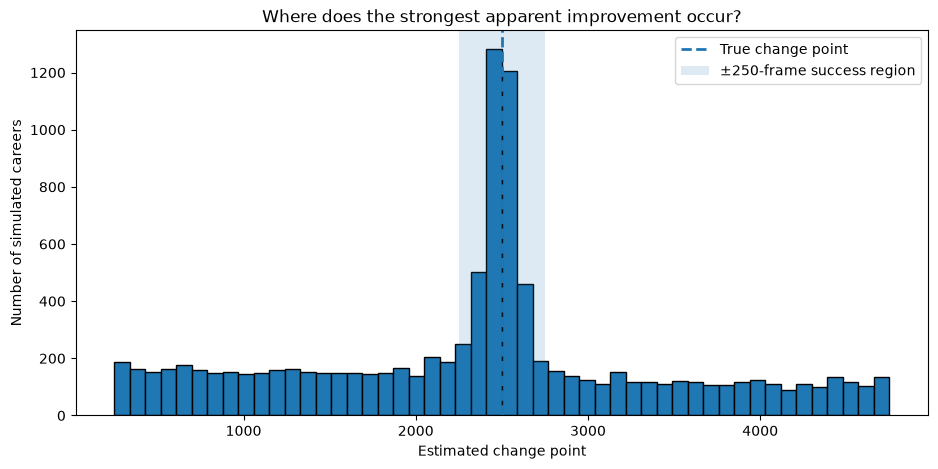

Absolute location error:

0–250 frames       3,829 careers (38.29%)
251–500 frames       899 careers ( 8.99%)
501–1,000 frames   1,498 careers (14.98%)
1,001–1,500 frames 1,492 careers (14.92%)
1,501–2,500 frames 2,282 careers (22.82%)


In [4]:
# Show the distribution of estimated change locations across all simulated careers.
#
# If the genuine signal dominates the search, we should see a strong
# concentration around the true change point at frame 2,500.
#
# If random competing peaks frequently win, the selected locations
# should be spread much more widely across the career.

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    estimated_points,
    bins=50,
    edgecolor="black",
)

ax.axvline(
    true_change_point,
    linestyle="--",
    linewidth=2,
    label="True change point",
)

ax.axvspan(
    true_change_point - location_tolerance,
    true_change_point + location_tolerance,
    alpha=0.15,
    label="±250-frame success region",
)

ax.set_title(
    "Where does the strongest apparent improvement occur?"
)
ax.set_xlabel("Estimated change point")
ax.set_ylabel("Number of simulated careers")
ax.legend()

plt.show()

# Also summarise how the location errors are distributed.
error_bands = [
    (0, 250),
    (251, 500),
    (501, 1_000),
    (1_001, 1_500),
    (1_501, 2_500),
]

print("Absolute location error:")
print()

for lower, upper in error_bands:
    if lower == 0:
        mask = location_errors <= upper
        label = f"0–{upper:,} frames"
    else:
        mask = (location_errors >= lower) & (location_errors <= upper)
        label = f"{lower:,}–{upper:,} frames"

    print(
        f"{label:18s} "
        f"{mask.sum():5,} careers "
        f"({mask.mean():6.2%})"
    )

## A real signal creates a peak, not certainty

The distribution of selected locations reveals something that the overall success rate alone hides.

There is a clear concentration around the genuine change point at frame **2,500**.

So the detector is not behaving randomly.

The permanent 58% → 64% improvement creates a real statistical signal, and that signal makes locations near the true change substantially more likely to be selected.

But the concentration sits on top of a broad background of detections spread across almost the entire searchable career.

The absolute errors were:

- **0–250 frames:** 38.29%;
- **251–500 frames:** 8.99%;
- **501–1,000 frames:** 14.98%;
- **1,001–1,500 frames:** 14.92%;
- **1,501–2,500 frames:** 22.82%.

This gives us a useful way to think about the problem.

The genuine change creates a **peak** in the distribution of estimated locations.

Random variation creates the **background**.

In some careers, the real signal produces the strongest contrast and the search lands near frame 2,500.

In others, an unrelated part of the career happens to produce an even larger before-versus-after difference and wins the search instead.

So these results should not be interpreted as saying that the detector has no information about the genuine change.

It clearly does.

But that information is not strong enough to dominate the thousands of competing opportunities for random variation in every career.

> **A genuine change makes the correct region more likely to stand out. It does not guarantee that it will stand out most.**

That distinction is important for eventually analysing real careers.

If an apparent change point emerges from a search, its location may contain genuine information.

But the fact that it was the strongest-looking point in the career is not, by itself, proof that it represents the player's true underlying change.

In [5]:
# Separate the search into two regions:
#
#   1. the region around the genuine change;
#   2. the rest of the searchable career.
#
# This lets us see directly what the detector is competing between.

signal_region_mask = (
    np.abs(candidate_points - true_change_point) <= location_tolerance
)
background_region_mask = ~signal_region_mask

# Re-run the simulations with the same seed so we can retain the
# strongest contrast inside and outside the genuine-change region.
comparison_rng = np.random.default_rng(1501)

best_signal_improvements = np.empty(n_careers, dtype=int)
best_background_improvements = np.empty(n_careers, dtype=int)

for batch_start in range(0, n_careers, batch_size):
    batch_end = min(batch_start + batch_size, n_careers)
    current_batch_size = batch_end - batch_start

    probabilities = np.empty((current_batch_size, career_length))
    probabilities[:, :true_change_point] = p_before
    probabilities[:, true_change_point:] = p_after

    careers = comparison_rng.binomial(1, probabilities)

    cumulative = np.concatenate(
        (
            np.zeros((current_batch_size, 1), dtype=int),
            np.cumsum(careers, axis=1),
        ),
        axis=1,
    )

    before_wins = (
        cumulative[:, candidate_points]
        - cumulative[:, candidate_points - window_size]
    )

    after_wins = (
        cumulative[:, candidate_points + window_size]
        - cumulative[:, candidate_points]
    )

    batch_improvements = after_wins - before_wins

    best_signal_improvements[batch_start:batch_end] = (
        batch_improvements[:, signal_region_mask].max(axis=1)
    )

    best_background_improvements[batch_start:batch_end] = (
        batch_improvements[:, background_region_mask].max(axis=1)
    )

signal_wins = best_signal_improvements > best_background_improvements
background_wins = best_background_improvements > best_signal_improvements
ties = best_signal_improvements == best_background_improvements

print("Strongest contrast by region:")
print()
print(
    f"Genuine-change region stronger: "
    f"{signal_wins.sum():,} careers ({signal_wins.mean():.2%})"
)
print(
    f"Background stronger:            "
    f"{background_wins.sum():,} careers ({background_wins.mean():.2%})"
)
print(
    f"Equal strongest contrast:       "
    f"{ties.sum():,} careers ({ties.mean():.2%})"
)
print()
print(
    f"Mean best contrast near true change: "
    f"+{best_signal_improvements.mean():.2f} wins"
)
print(
    f"Mean best contrast elsewhere:        "
    f"+{best_background_improvements.mean():.2f} wins"
)
print()
print(
    f"Median best contrast near true change: "
    f"+{np.median(best_signal_improvements):.0f} wins"
)
print(
    f"Median best contrast elsewhere:        "
    f"+{np.median(best_background_improvements):.0f} wins"
)

Strongest contrast by region:

Genuine-change region stronger: 3,669 careers (36.69%)
Background stronger:            5,923 careers (59.23%)
Equal strongest contrast:       408 careers (4.08%)

Mean best contrast near true change: +27.10 wins
Mean best contrast elsewhere:        +29.51 wins

Median best contrast near true change: +27 wins
Median best contrast elsewhere:        +29 wins


## The real change has to compete with the rest of the career

We can now see the competition directly.

For each simulated career, we separated the search into:

- the **genuine-change region**, within 250 frames of the true change point;
- the **background**, containing every other searchable location.

We then asked which region produced the larger apparent before-versus-after improvement.

Across 10,000 careers:

- genuine-change region stronger: **36.69%**;
- background stronger: **59.23%**;
- equal strongest contrast: **4.08%**.

The background therefore produced a strictly larger apparent improvement in almost **six careers out of ten**.

The size of those competing peaks also tells the story.

Near the true change:

- mean best contrast = **+27.10 wins**;
- median best contrast = **+27 wins**.

Elsewhere in the career:

- mean best contrast = **+29.51 wins**;
- median best contrast = **+29 wins**.

This might initially seem surprising.

There really is a 58% → 64% improvement around frame 2,500, while the rest of the career contains no additional genuine changes.

But the genuine-change region is only one relatively small part of the search.

The background contains thousands of opportunities for random variation to produce an unusually weak 250-frame period followed by an unusually strong one.

The true change therefore has an advantage in **signal strength**.

The rest of the career has an advantage in **number of opportunities**.

In this experiment, that opportunity advantage is often enough to win.

> **The detector is not choosing between a real change and one random alternative. It is choosing between the real change and thousands of chances for randomness to imitate one.**

This connects Studies 14 and 15 directly.

Study 14 showed that searching many locations makes extreme random runs easy to find.

Study 15 shows why that remains important even after a genuine signal is introduced:

> **The real signal must compete against the same look-elsewhere effect.**

That is why the genuine change creates a clear concentration around frame 2,500 while still failing to become the strongest apparent change in most individual careers.

In [6]:
# The ±250-frame success rule was chosen before looking at the repeated
# simulations, but it is still useful to see how localisation performance
# changes under stricter or looser definitions of "close".
#
# Nothing about the simulated careers or detector changes here.
# We are only summarising the same location_errors at several tolerances.

tolerances = np.array([50, 100, 250, 500, 1_000])

print("Success rate by allowed location error:")
print()

for tolerance in tolerances:
    success = location_errors <= tolerance

    print(
        f"Within ±{tolerance:>4,} frames: "
        f"{success.sum():5,} careers "
        f"({success.mean():6.2%})"
    )

# Also report a few percentiles of the absolute error distribution.
print()
print("Absolute location-error percentiles:")
print()

for percentile in [25, 50, 75, 90]:
    value = np.percentile(location_errors, percentile)

    print(
        f"{percentile:>2}th percentile: "
        f"{value:,.0f} frames"
    )

Success rate by allowed location error:

Within ±  50 frames: 1,728 careers (17.28%)
Within ± 100 frames: 2,636 careers (26.36%)
Within ± 250 frames: 3,829 careers (38.29%)
Within ± 500 frames: 4,728 careers (47.28%)
Within ±1,000 frames: 6,226 careers (62.26%)

Absolute location-error percentiles:

25th percentile: 91 frames
50th percentile: 589 frames
75th percentile: 1,429 frames
90th percentile: 1,936 frames


## Localisation accuracy depends strongly on how close we require the detector to get

Our main success criterion allowed the estimated change point to fall within **250 frames** of the genuine change.

Under that rule, the detector succeeded in **38.29%** of careers.

But the same results can be judged at different tolerances:

- within ±50 frames: **17.28%**;
- within ±100 frames: **26.36%**;
- within ±250 frames: **38.29%**;
- within ±500 frames: **47.28%**;
- within ±1,000 frames: **62.26%**.

So there is no single localisation percentage that exists independently of how precisely we demand the change to be identified.

The error distribution makes the same point.

Absolute location-error percentiles were:

- 25th percentile: **91 frames**;
- median: **589 frames**;
- 75th percentile: **1,429 frames**;
- 90th percentile: **1,936 frames**.

The lower end of the distribution shows that the detector can sometimes be very accurate.

In one quarter of careers, it gets within about **91 frames** of the genuine change.

But the long upper tail is equally important.

Half of all careers miss the true change by more than **589 frames**, and one quarter miss it by more than **1,429 frames**.

This reinforces what the histogram already suggested.

There is a real concentration of estimates near the genuine change, but there is also a large population of searches in which an unrelated random peak wins by a wide margin.

> **The detector contains useful information about where the change happened, but its location estimate is highly unreliable in many individual careers.**

That distinction matters.

A method can be informative on average without being dependable every time.

For a real player's career, finding an apparent change near a plausible period would therefore be evidence worth investigating, but not something we should automatically treat as a precisely identified breakpoint.

In [7]:
# Compare Study 15 with a matched no-change world.
#
# Everything about the search remains identical:
#
#   - 5,000-frame careers;
#   - 250 frames before versus 250 frames after;
#   - search every possible candidate point;
#   - retain only the largest apparent improvement.
#
# The only difference is that these control players remain at 58%
# throughout the whole career.

null_rng = np.random.default_rng(1502)

null_strongest_improvements = np.empty(n_careers, dtype=int)

for batch_start in range(0, n_careers, batch_size):
    batch_end = min(batch_start + batch_size, n_careers)
    current_batch_size = batch_end - batch_start

    # No genuine change anywhere in the career.
    careers = null_rng.binomial(
        1,
        p_before,
        size=(current_batch_size, career_length),
    )

    cumulative = np.concatenate(
        (
            np.zeros((current_batch_size, 1), dtype=int),
            np.cumsum(careers, axis=1),
        ),
        axis=1,
    )

    before_wins = (
        cumulative[:, candidate_points]
        - cumulative[:, candidate_points - window_size]
    )

    after_wins = (
        cumulative[:, candidate_points + window_size]
        - cumulative[:, candidate_points]
    )

    improvements = after_wins - before_wins

    null_strongest_improvements[batch_start:batch_end] = (
        improvements.max(axis=1)
    )

print("Strongest apparent improvement anywhere in the career:")
print()

print("No genuine change:")
print(
    f"  mean:   +{null_strongest_improvements.mean():.2f} wins"
)
print(
    f"  median: +{np.median(null_strongest_improvements):.0f} wins"
)
print()

print("Genuine 58% -> 64% change:")
print(
    f"  mean:   +{strongest_improvements.mean():.2f} wins"
)
print(
    f"  median: +{np.median(strongest_improvements):.0f} wins"
)

print()
print("Selected percentiles:")
print()

for percentile in [5, 25, 50, 75, 95]:
    null_value = np.percentile(
        null_strongest_improvements,
        percentile,
    )
    change_value = np.percentile(
        strongest_improvements,
        percentile,
    )

    print(
        f"{percentile:>2}th percentile: "
        f"no change +{null_value:>4.0f} wins | "
        f"genuine change +{change_value:>4.0f} wins"
    )

Strongest apparent improvement anywhere in the career:

No genuine change:
  mean:   +30.36 wins
  median: +30 wins

Genuine 58% -> 64% change:
  mean:   +32.11 wins
  median: +31 wins

Selected percentiles:

 5th percentile: no change +  23 wins | genuine change +  24 wins
25th percentile: no change +  27 wins | genuine change +  28 wins
50th percentile: no change +  30 wins | genuine change +  31 wins
75th percentile: no change +  33 wins | genuine change +  35 wins
95th percentile: no change +  40 wins | genuine change +  42 wins


## The strongest contrast barely distinguishes real change from no change

The matched control makes the problem even clearer.

When there was **no genuine change anywhere** in the career, the strongest apparent improvement found by the search was:

- mean = **+30.36 wins**;
- median = **+30 wins**.

When every career contained a genuine permanent **58% → 64%** improvement, the strongest apparent improvement was:

- mean = **+32.11 wins**;
- median = **+31 wins**.

So introducing a real six-percentage-point ability change increased the mean strongest contrast by only:

$$
32.11 - 30.36 = 1.75 \text{ wins}
$$

The distributions overlap heavily.

Selected percentiles show how similar they are:

| Percentile | No change | Genuine change |
|---:|---:|---:|
| 5th | +23 wins | +24 wins |
| 25th | +27 wins | +28 wins |
| 50th | +30 wins | +31 wins |
| 75th | +33 wins | +35 wins |
| 95th | +40 wins | +42 wins |

This is an important warning about using the **size of the single strongest contrast** as evidence.

A career containing a genuine change does tend to produce a slightly larger maximum.

But ordinary random variation, after a whole-career search, already produces very large apparent changes.

The genuine signal is therefore added on top of an extreme-value background that is already substantial.

> **The largest apparent change in a career can look almost equally impressive whether a genuine change occurred or not.**

That helps explain the localisation result.

When the real change creates the strongest contrast, the detector can land near the correct region.

But many unchanged parts of the career can independently generate contrasts almost as large — and sometimes larger.

So the problem is now broader than simply finding a conspicuous jump.

> **We need evidence that distinguishes a persistent underlying change from the extreme random contrasts that searching itself creates.**

That is a problem for later studies.

For Study 15, the simpler result is enough:

> **A genuine ability change creates a detectable signal, but neither the location nor the magnitude of the strongest searched contrast can be trusted automatically.**

In [8]:
# Use the no-change simulations to choose a whole-career threshold.
#
# We want the smallest integer contrast for which no more than 5% of
# completely unchanged careers produce a maximum at least that large.
#
# This automatically accounts for the fact that we searched the whole
# career before retaining the strongest contrast.

possible_thresholds = np.arange(
    null_strongest_improvements.min(),
    null_strongest_improvements.max() + 2,
)

null_false_alarm_rates = np.array([
    np.mean(null_strongest_improvements >= threshold)
    for threshold in possible_thresholds
])

threshold_index = np.flatnonzero(
    null_false_alarm_rates <= 0.05
)[0]

detection_threshold = possible_thresholds[threshold_index]
false_alarm_rate = null_false_alarm_rates[threshold_index]

# Apply exactly the same threshold to careers containing the genuine
# 58% -> 64% change.
detected_change = strongest_improvements >= detection_threshold

# Of the genuine-change careers that clear the threshold, ask whether
# the selected strongest location was actually near the real change.
detected_and_correct = detected_change & correctly_located

print("Search-adjusted 5% detection rule:")
print()
print(
    f"Threshold: strongest contrast >= "
    f"+{detection_threshold} wins"
)
print(
    f"No-change false-alarm rate: "
    f"{false_alarm_rate:.2%}"
)
print()
print(
    f"Genuine-change careers exceeding threshold: "
    f"{detected_change.sum():,} "
    f"({detected_change.mean():.2%})"
)
print()
print(
    f"Detected AND correctly located: "
    f"{detected_and_correct.sum():,} "
    f"({detected_and_correct.mean():.2%} of all changed careers)"
)

if detected_change.sum() > 0:
    print(
        f"Correctly located among detected careers: "
        f"{detected_and_correct.sum() / detected_change.sum():.2%}"
    )

Search-adjusted 5% detection rule:

Threshold: strongest contrast >= +41 wins
No-change false-alarm rate: 3.59%

Genuine-change careers exceeding threshold: 768 (7.68%)

Detected AND correctly located: 489 (4.89% of all changed careers)
Correctly located among detected careers: 63.67%


## Controlling false alarms makes the detector much less sensitive

The no-change simulations allow us to choose a threshold that accounts for the **entire career search** rather than judging one location in isolation.

The first whole-career threshold with a false-alarm rate below 5% was:

- strongest contrast of at least **+41 wins**;
- no-change false-alarm rate = **3.59%**.

We can now apply that same rule to careers that really contain the permanent 58% → 64% improvement.

Only:

- **768 of 10,000 careers**;
- **7.68%**

produced a strongest contrast large enough to cross the threshold.

So a rule that is reasonably resistant to false discoveries has very low sensitivity to this genuine change.

More importantly, crossing the threshold and locating the change are separate problems.

Only:

- **489 of 10,000 changed careers**;
- **4.89%**

both exceeded the detection threshold **and** placed the strongest contrast within 250 frames of the true change.

Among the relatively small number of careers that did cross the threshold, localisation was much better:

$$
\frac{489}{768} = 63.67\%
$$

So unusually strong detections are more likely to point toward the genuine change.

But they are also rare.

This exposes a difficult trade-off.

If we simply choose the strongest-looking point in every career, we obtain some information about the true location, but random peaks frequently win.

If we demand evidence strong enough to be unusual after a whole-career search, false alarms become uncommon — but we fail to detect most genuine 58% → 64% changes.

> **Protecting ourselves against false discoveries can make real changes much harder to detect.**

The detector therefore faces two different failure modes:

- a permissive search frequently mistakes random peaks for the most important change;
- a strict search avoids many of those false signals but misses most genuine changes.

This is not a defect in the simulation.

It is the statistical difficulty Study 15 was designed to reveal.

> **When the signal is modest and the search space is large, there may be no simple threshold that gives both reliable detection and reliable localisation.**

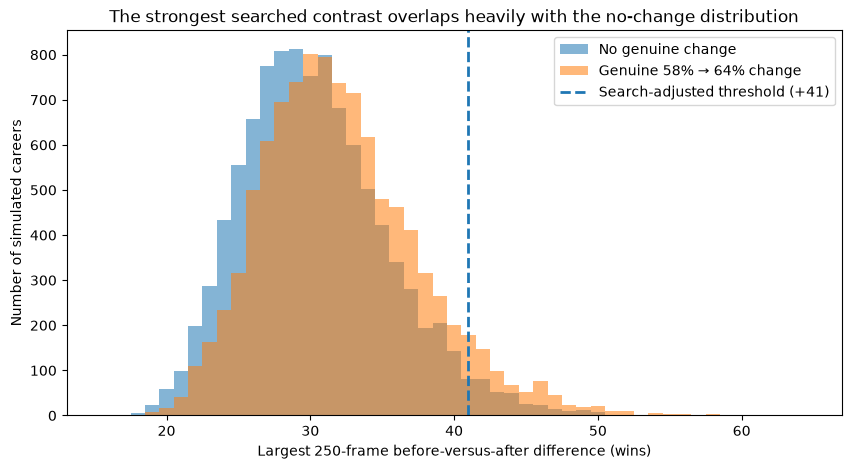

In [9]:
# Visualise the distribution of the strongest contrast found anywhere
# in each career under the two worlds:
#
#   - no genuine change;
#   - one genuine 58% -> 64% permanent change.
#
# If the maximum searched contrast were a strong detector, these
# distributions would be clearly separated.

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.arange(
    min(
        null_strongest_improvements.min(),
        strongest_improvements.min(),
    ) - 0.5,
    max(
        null_strongest_improvements.max(),
        strongest_improvements.max(),
    ) + 1.5,
    1,
)

ax.hist(
    null_strongest_improvements,
    bins=bins,
    alpha=0.55,
    label="No genuine change",
)

ax.hist(
    strongest_improvements,
    bins=bins,
    alpha=0.55,
    label="Genuine 58% → 64% change",
)

ax.axvline(
    detection_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Search-adjusted threshold (+{detection_threshold})",
)

ax.set_title(
    "The strongest searched contrast overlaps heavily "
    "with the no-change distribution"
)
ax.set_xlabel("Largest 250-frame before-versus-after difference (wins)")
ax.set_ylabel("Number of simulated careers")
ax.legend()

plt.show()

## The distributions overlap almost completely

The visual comparison makes the detection problem difficult to miss.

Careers containing a genuine permanent 58% → 64% improvement are shifted slightly toward larger maximum contrasts.

But the shift is small relative to the overall spread.

Most of the two distributions occupy the same range.

A strongest contrast of around **30 wins**, for example, is entirely ordinary under both worlds:

- it can arise when a genuine change is present;
- it can also arise when the player's ability never changed at all.

Even contrasts substantially larger than this remain possible under the no-change model because we deliberately searched the whole career and retained only the most extreme result.

The dashed line at **+41 wins** shows the search-adjusted threshold chosen from the no-change simulations.

Most careers lie to the left of it.

That includes:

- the great majority of unchanged careers, as intended;
- but also the great majority of careers containing the genuine 58% → 64% improvement.

The genuine-change distribution has a somewhat heavier right tail, but there is no clean separation.

This explains the low detection rate quantitatively.

> **The strongest searched contrast is not a reliable classifier of whether a genuine change occurred.**

The problem is not that the real change leaves no trace.

It does shift the distribution.

The problem is that the shift is modest compared with the extreme random variation produced by searching thousands of candidate locations.

So an impressive maximum is ambiguous:

> **A large apparent change may be the amplified footprint of a real change, or simply the largest random contrast that a long search happened to uncover.**

This is why looking only at the single most dramatic period throws away too much information.

For now, however, that limitation is useful.

Study 15 was intended to discover whether a very simple whole-career search could reliably find a hidden genuine change.

The answer is becoming clear:

> **It can often see the signal in aggregate, but it cannot reliably identify the correct change in an individual career.**

In [10]:
# Compare the detector's localisation rate with a simple random-location baseline.
#
# There are 4,501 searchable candidate points in total.
# Our success region contains every candidate within ±250 frames of
# the genuine change point.
#
# If an estimated location were chosen uniformly at random from all
# searchable points, its probability of landing in that region would
# simply be the fraction of candidate points that the region occupies.

success_region_points = candidate_points[
    np.abs(candidate_points - true_change_point) <= location_tolerance
]

random_location_success_rate = (
    len(success_region_points) / len(candidate_points)
)

detector_success_rate = correctly_located.mean()

relative_lift = (
    detector_success_rate / random_location_success_rate
)

print(f"Searchable candidate points: {len(candidate_points):,}")
print(
    f"Candidate points inside ±{location_tolerance}-frame "
    f"success region: {len(success_region_points):,}"
)
print()
print(
    f"Random-location success rate: "
    f"{random_location_success_rate:.2%}"
)
print(
    f"Detector success rate:        "
    f"{detector_success_rate:.2%}"
)
print()
print(
    f"Detector / random baseline:   "
    f"{relative_lift:.2f}×"
)

Searchable candidate points: 4,501
Candidate points inside ±250-frame success region: 501

Random-location success rate: 11.13%
Detector success rate:        38.29%

Detector / random baseline:   3.44×


## The detector is informative even though it is not reliable

The localisation success rate of **38.29%** sounds poor in isolation.

But the detector should not be compared with perfection.

It should also be compared with what would happen if we had no useful information about the change location at all.

There are **4,501 searchable candidate points** in the career.

Our ±250-frame success region contains **501** of them.

If we simply selected one searchable location at random, the probability of landing inside that region would therefore be:

$$
\frac{501}{4501} = 11.13\%
$$

The detector succeeds:

$$
38.29\%
$$

of the time.

That is about:

$$
\frac{38.29}{11.13} = 3.44
$$

times the random-location baseline.

So the detector clearly contains real information about where the genuine change occurred.

The problem is not that it is useless.

The problem is that it is **not reliable enough to trust automatically in an individual career**.

This distinction is important.

The genuine 58% → 64% improvement creates enough structure that the strongest contrast is much more likely than chance to occur near the true change.

But in most careers, some competing random peak still produces the largest observed contrast.

> **The search is informative without being dependable.**

That is a more precise conclusion than simply saying that the detector succeeds or fails.

Across many careers, the genuine signal pulls estimated locations toward the correct region.

For one particular career, however, we cannot know from the strongest contrast alone whether we have found that genuine signal or one of the many random alternatives.

This is the bridge we needed.

> **A hidden ability change can leave a detectable statistical footprint without giving us a trustworthy single estimate of exactly where it happened.**

## Conclusion

Study 15 asked:

> **If a genuine improvement happened somewhere in the career, can a search through noisy results correctly identify where it occurred?**

In this deliberately simple experiment, every changed career contained the same permanent improvement:

- 58% before frame 2,500;
- 64% afterwards;
- 5,000 frames in total;
- one fixed 250-frame before-versus-after comparison;
- no opponent effects;
- no momentum;
- no parameter uncertainty;
- no alternative window lengths;
- no formal change-point algorithm.

The detector was given only the wins and losses.

It searched all **4,501 possible locations** and retained the largest observed improvement.

The genuine change clearly left a signal.

Estimated locations clustered strongly around frame 2,500, and the detector landed within ±250 frames of the true change in **38.29%** of careers.

A random location would succeed only **11.13%** of the time.

So the search was about **3.44 times better than chance** at locating the genuine change region.

But that is only half the story.

In **61.71%** of careers, the strongest apparent improvement occurred more than 250 frames away from the true change.

The median absolute location error was **589 frames**.

Why?

Because the real signal had to compete with thousands of opportunities for random variation elsewhere in the career.

When we compared the regions directly:

- the genuine-change region produced the strictly strongest contrast in **36.69%** of careers;
- the background produced the strictly strongest contrast in **59.23%**;
- **4.08%** were tied.

The real change therefore created a local advantage.

The rest of the career created an opportunity advantage.

And the opportunity advantage frequently won.

The magnitude of the strongest contrast was also misleading.

With no genuine change, the mean maximum contrast was already:

**+30.36 wins**

With the genuine 58% → 64% change, it increased only to:

**+32.11 wins**

The two distributions overlapped heavily.

Using a whole-career search-adjusted threshold of **+41 wins** reduced the no-change false-alarm rate to **3.59%**.

But only **7.68%** of careers containing the genuine change crossed that threshold.

Only **4.89%** both crossed it and located the genuine change within ±250 frames.

So stricter evidence reduced false discoveries at the cost of missing most genuine changes.

The central result is therefore not that the simple detector works or does not work.

It is more subtle:

> **A genuine ability change can leave a detectable statistical footprint without making its location reliably identifiable in one noisy career.**

Study 13 showed:

> **A change can be recognised much more easily when we are told where to look.**

Study 14 showed:

> **Searching everywhere can manufacture exceptional-looking evidence even when nothing changed.**

Study 15 combines those problems:

> **When something really did change, the genuine signal must compete with all the random peaks created by searching everywhere else.**

That gives us an important warning before moving to real player careers.

Finding the strongest apparent change is not enough.

We must eventually distinguish:

- genuine persistent changes in underlying ability;
- ordinary sampling variation;
- and extreme observations produced simply because we searched many possible locations.

For now, the deliberately simple search has done its job.

It has shown why finding a real change is a harder problem than merely noticing that part of a career looks different.

> **The strongest-looking change is not necessarily the real change.**